# IMPROVISATION #2: COST-SENSITIVE LEARNING


## Cell 1: Library Imports and Configuration


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.linear_model import LogisticRegression as LR
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier as RF
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_predict, cross_validate
from sklearn.metrics import (balanced_accuracy_score, recall_score, precision_score, 
                             f1_score, confusion_matrix, classification_report,
                             make_scorer)
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

print("All imports successful.")

All imports successful.



# Cell 2: Load and prepare data

In [2]:


data = pd.read_csv("Thyroid_Diff.csv")
X = data.drop("Recurred", axis=1)
y = data["Recurred"].map({"No": 0, "Yes": 1})

print("="*60)
print("DATA LOADED")
print("="*60)
print(f"Total samples: {len(data)}")
print(f"Recurrence: {sum(y==1)}, Non-recurrence: {sum(y==0)}")

DATA LOADED
Total samples: 383
Recurrence: 108, Non-recurrence: 275


# Cell 3: Preprocessor

In [3]:



num_features = list(X.columns[:1])
cat_features = list(X.columns[1:])

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ],
    remainder='passthrough'
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, 
                                                     random_state=321, stratify=y)

# Transform
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
X_full_transformed = preprocessor.fit_transform(X)

print(f"\nTraining: {X_train_transformed.shape}")
print(f"Test: {X_test_transformed.shape}")
print(f"Full: {X_full_transformed.shape}")


Training: (287, 55)
Test: (96, 55)
Full: (383, 55)


In [4]:


try:
    from umap import UMAP
    umap_available = True
    print("\n UMAP available - using non-linear dimensionality reduction")
except ImportError:
    umap_available = False
    print("\n UMAP not available - using PCA as fallback")


 UMAP available - using non-linear dimensionality reduction


# Cell 5: Function to build ensemble with given class weights

In [7]:

def build_weighted_ensemble(class_weights, name=""):
    """Build stacking ensemble with specified class weights"""
    
    # PCA + Logistic Regression
    pca_lr = Pipeline([
        ('pca', PCA(n_components=5)),
        ('clf', LR(C=0.36, penalty='l1', solver='liblinear', 
                   class_weight=class_weights, random_state=42, max_iter=1000))
    ])
    
    # t-SVD + SVM
    tsvd_svm = Pipeline([
        ('tsvd', TruncatedSVD(n_components=5)),
        ('clf', SVC(probability=True, C=0.25, kernel='sigmoid', 
                    class_weight=class_weights, random_state=42))
    ])
    
    # UMAP/PCA + Random Forest
    if umap_available:
        rf_transformer = UMAP(n_components=5, random_state=42, n_neighbors=15, min_dist=0.1)
    else:
        rf_transformer = PCA(n_components=5)
    
    rf_model = Pipeline([
        ('transformer', rf_transformer),
        ('clf', RF(criterion='entropy', max_depth=None, max_features='log2',
                   min_samples_leaf=4, n_estimators=200,  # Reduced for speed
                   class_weight=class_weights, random_state=42))
    ])
    
    estimators = [
        ('lr_pca', pca_lr),
        ('svm_tsvd', tsvd_svm),
        ('rf_model', rf_model)
    ]
    
    meta_learner = LR(C=0.1, penalty='l2', solver='liblinear', 
                      class_weight=class_weights, random_state=42)
    
    return StackingClassifier(estimators=estimators, 
                             final_estimator=meta_learner,
                             cv=3,  # Reduced CV folds for speed
                             stack_method='predict_proba', 
                             n_jobs=-1)


# Cell 6: Define fine-grained penalty configurations

In [9]:


print("\n" + "="*60)
print("FINE-GRAINED COST CONFIGURATIONS")
print("="*60)

# Focus on moderate penalties around the successful 2x
penalties = [1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.5, 3.0]

configs = []

for penalty in penalties:
    if penalty == 1.0:
        class_weights = 'balanced'
        name = f"Baseline (1.0x)"
    else:
        class_weights = {0: 1.0, 1: penalty}
        name = f"FN Penalty {penalty}x"
    
    configs.append({
        'name': name,
        'class_weights': class_weights,
        'fn_cost': penalty
    })
    
    print(f"\n{name}: FN Cost = {penalty:.1f}x")


FINE-GRAINED COST CONFIGURATIONS

Baseline (1.0x): FN Cost = 1.0x

FN Penalty 1.2x: FN Cost = 1.2x

FN Penalty 1.4x: FN Cost = 1.4x

FN Penalty 1.6x: FN Cost = 1.6x

FN Penalty 1.8x: FN Cost = 1.8x

FN Penalty 2.0x: FN Cost = 2.0x

FN Penalty 2.2x: FN Cost = 2.2x

FN Penalty 2.5x: FN Cost = 2.5x

FN Penalty 3.0x: FN Cost = 3.0x




# Cell 7: Train and evaluate all configurations 

In [10]:

print("\n" + "="*60)
print("TRAINING COST-SENSITIVE ENSEMBLES")
print("="*60)

# First, identify Bilateral subgroup
bilateral_mask = data['Adenopathy'] == 'Bilateral'
X_bilateral = X_full_transformed[bilateral_mask]
y_bilateral = y[bilateral_mask]

print(f"\n BILATERAL SUBGROUP:")
print(f"   Sample size: {len(y_bilateral)}")
print(f"   Recurrence rate: {y_bilateral.mean()*100:.1f}%")
print(f"   Target: Improve specificity from 0.0")

bilateral_results = []
test_results = []

for cfg in configs:
    print(f"\nTraining {cfg['name']}...")
    ensemble = build_weighted_ensemble(cfg['class_weights'])
    ensemble.fit(X_train_transformed, y_train)
    
    # Test set evaluation
    y_pred_test = ensemble.predict(X_test_transformed)
    y_proba_test = ensemble.predict_proba(X_test_transformed)[:, 1]
    
    test_results.append({
        'Configuration': cfg['name'],
        'FN Cost': cfg['fn_cost'],
        'Test Balanced Acc': balanced_accuracy_score(y_test, y_pred_test),
        'Test Sensitivity': recall_score(y_test, y_pred_test, pos_label=1),
        'Test Specificity': recall_score(y_test, y_pred_test, pos_label=0)
    })
    
    # Bilateral subgroup evaluation
    y_pred_bilateral = ensemble.predict(X_bilateral)
    
    if len(np.unique(y_bilateral)) > 1:
        bal_acc = balanced_accuracy_score(y_bilateral, y_pred_bilateral)
        sensitivity = recall_score(y_bilateral, y_pred_bilateral, pos_label=1)
        specificity = recall_score(y_bilateral, y_pred_bilateral, pos_label=0)
    else:
        bal_acc = sensitivity = specificity = 0.0
    
    bilateral_results.append({
        'Configuration': cfg['name'],
        'FN Cost': cfg['fn_cost'],
        'Bilateral Balanced Acc': bal_acc,
        'Bilateral Sensitivity': sensitivity,
        'Bilateral Specificity': specificity,
        'Improvement from Baseline': specificity - 0.0
    })
    
    print(f"   Test Balanced Acc: {test_results[-1]['Test Balanced Acc']:.4f}")
    print(f"   Bilateral Specificity: {specificity:.4f}")


TRAINING COST-SENSITIVE ENSEMBLES

 BILATERAL SUBGROUP:
   Sample size: 32
   Recurrence rate: 84.4%
   Target: Improve specificity from 0.0

Training Baseline (1.0x)...
   Test Balanced Acc: 0.9195
   Bilateral Specificity: 0.0000

Training FN Penalty 1.2x...
   Test Balanced Acc: 0.9227
   Bilateral Specificity: 0.6000

Training FN Penalty 1.4x...
   Test Balanced Acc: 0.9227
   Bilateral Specificity: 0.4000

Training FN Penalty 1.6x...
   Test Balanced Acc: 0.9340
   Bilateral Specificity: 0.4000

Training FN Penalty 1.8x...
   Test Balanced Acc: 0.9267
   Bilateral Specificity: 0.2000

Training FN Penalty 2.0x...
   Test Balanced Acc: 0.9267
   Bilateral Specificity: 0.2000

Training FN Penalty 2.2x...
   Test Balanced Acc: 0.9195
   Bilateral Specificity: 0.0000

Training FN Penalty 2.5x...
   Test Balanced Acc: 0.9195
   Bilateral Specificity: 0.0000

Training FN Penalty 3.0x...
   Test Balanced Acc: 0.9235
   Bilateral Specificity: 0.0000


# Cell 8: Display results

In [11]:



print("\n" + "="*60)
print(" BILATERAL SUBGROUP RESULTS")
print("="*60)

bilateral_df = pd.DataFrame(bilateral_results)
print(bilateral_df.round(4).to_string(index=False))

print("\n" + "="*60)
print(" TEST SET RESULTS")
print("="*60)

test_df = pd.DataFrame(test_results)
print(test_df.round(4).to_string(index=False))


 BILATERAL SUBGROUP RESULTS
  Configuration  FN Cost  Bilateral Balanced Acc  Bilateral Sensitivity  Bilateral Specificity  Improvement from Baseline
Baseline (1.0x)      1.0                     0.5                    1.0                    0.0                        0.0
FN Penalty 1.2x      1.2                     0.8                    1.0                    0.6                        0.6
FN Penalty 1.4x      1.4                     0.7                    1.0                    0.4                        0.4
FN Penalty 1.6x      1.6                     0.7                    1.0                    0.4                        0.4
FN Penalty 1.8x      1.8                     0.6                    1.0                    0.2                        0.2
FN Penalty 2.0x      2.0                     0.6                    1.0                    0.2                        0.2
FN Penalty 2.2x      2.2                     0.5                    1.0                    0.0                       


# Cell 9: Find optimal configuration for Bilateral

In [12]:


print("\n" + "="*60)
print(" OPTIMAL CONFIGURATION FOR BILATERAL")
print("="*60)

# Find best based on specificity (primary metric)
best_specificity = bilateral_df.loc[bilateral_df['Bilateral Specificity'].idxmax()]
best_tradeoff = bilateral_df.loc[(bilateral_df['Bilateral Specificity'] > 0) & 
                                  (bilateral_df['Bilateral Sensitivity'] > 0.5)].head(1)

if len(best_tradeoff) > 0:
    best_config = best_tradeoff.iloc[0]
else:
    best_config = best_specificity

print(f"\n BEST CONFIGURATION: {best_config['Configuration']}")
print(f"   FN Cost: {best_config['FN Cost']:.1f}x")
print(f"   Bilateral Specificity: {best_config['Bilateral Specificity']:.4f} (Original: 0.0)")
print(f"   Bilateral Sensitivity: {best_config['Bilateral Sensitivity']:.4f}")
print(f"   Improvement: +{best_config['Improvement from Baseline']:.4f}")


 OPTIMAL CONFIGURATION FOR BILATERAL

 BEST CONFIGURATION: FN Penalty 1.2x
   FN Cost: 1.2x
   Bilateral Specificity: 0.6000 (Original: 0.0)
   Bilateral Sensitivity: 1.0000
   Improvement: +0.6000




# Cell 10: Build final ensemble using best config + ensemble of good configs

In [13]:

print("\n" + "="*60)
print("🔧 BUILDING FINAL ENSEMBLE (Voting of Top 3 Cost-Sensitive Models)")
print("="*60)

# Get top 3 configurations based on Bilateral specificity
top_configs = bilateral_df.nlargest(3, 'Bilateral Specificity')
print("\nTop 3 configurations:")
print(top_configs[['Configuration', 'FN Cost', 'Bilateral Specificity']])

# Build voting ensemble of top cost-sensitive models
voting_estimators = []

for idx, row in top_configs.iterrows():
    cfg_name = row['Configuration']
    fn_cost = row['FN Cost']
    
    if fn_cost == 1.0:
        class_weights = 'balanced'
    else:
        class_weights = {0: 1.0, 1: fn_cost}
    
    ensemble = build_weighted_ensemble(class_weights)
    ensemble.fit(X_train_transformed, y_train)
    
    voting_estimators.append((f"cost_{fn_cost}x", ensemble))

# Create voting classifier
voting_ensemble = VotingClassifier(
    estimators=voting_estimators,
    voting='soft'  # Use probability averaging
)

voting_ensemble.fit(X_train_transformed, y_train)

# Evaluate voting ensemble on Bilateral
y_pred_bilateral_voting = voting_ensemble.predict(X_bilateral)
y_pred_test_voting = voting_ensemble.predict(X_test_transformed)

if len(np.unique(y_bilateral)) > 1:
    voting_specificity = recall_score(y_bilateral, y_pred_bilateral_voting, pos_label=0)
    voting_sensitivity = recall_score(y_bilateral, y_pred_bilateral_voting, pos_label=1)
    voting_bal_acc = balanced_accuracy_score(y_bilateral, y_pred_bilateral_voting)
else:
    voting_specificity = voting_sensitivity = voting_bal_acc = 0.0

voting_test_bal_acc = balanced_accuracy_score(y_test, y_pred_test_voting)

print(f"\n VOTING ENSEMBLE RESULTS:")
print(f"   Bilateral Specificity: {voting_specificity:.4f}")
print(f"   Bilateral Sensitivity: {voting_sensitivity:.4f}")
print(f"   Test Balanced Accuracy: {voting_test_bal_acc:.4f}")


🔧 BUILDING FINAL ENSEMBLE (Voting of Top 3 Cost-Sensitive Models)

Top 3 configurations:
     Configuration  FN Cost  Bilateral Specificity
1  FN Penalty 1.2x      1.2                    0.6
2  FN Penalty 1.4x      1.4                    0.4
3  FN Penalty 1.6x      1.6                    0.4


NameError: name 'VotingClassifier' is not defined


# Cell 11: 10-fold CV on best individual configuration

In [ ]:


print("\n" + "="*60)
print("10-FOLD CV - BEST INDIVIDUAL CONFIGURATION")
print("="*60)

best_fn_cost = best_config['FN Cost']
if best_fn_cost == 1.0:
    best_weights = 'balanced'
else:
    best_weights = {0: 1.0, 1: best_fn_cost}

best_ensemble = build_weighted_ensemble(best_weights)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'roc_auc': 'roc_auc',
    'sensitivity': make_scorer(recall_score, pos_label=1),
    'specificity': make_scorer(recall_score, pos_label=0)
}

cv_results = cross_validate(best_ensemble, X_train_transformed, y_train,
                           cv=cv, scoring=scoring, n_jobs=-1)

print("\n10-FOLD CV RESULTS:")
for metric in scoring.keys():
    mean_score = cv_results[f'test_{metric}'].mean()
    std_score = cv_results[f'test_{metric}'].std()
    print(f"  {metric:20}: {mean_score:.4f} ± {std_score:.4f}")



# Cell 12: Final comparison with Friend's ensemble

In [ ]:

print("\n" + "="*60)
print(" FINAL COMPARISON: FRIEND'S ENSEMBLE vs IMPROVED COST-SENSITIVE")
print("="*60)

# Friend's results
friend_results = {
    'Model': "Friend's Stacking Ensemble",
    'Test Balanced Acc': 0.920,
    'CV Balanced Acc': 0.861,
    'Test-CV Gap': 0.059,
    'Bilateral Specificity': 0.000,
    'Bilateral Improvement': 0.000
}

# Best cost-sensitive individual
best_test_acc = test_df.loc[test_df['Configuration'] == best_config['Configuration'], 'Test Balanced Acc'].values[0]

cost_results = {
    'Model': f"Cost-Sensitive ({best_config['FN Cost']:.1f}x FN penalty)",
    'Test Balanced Acc': best_test_acc,
    'CV Balanced Acc': cv_results['test_balanced_accuracy'].mean(),
    'Test-CV Gap': abs(best_test_acc - cv_results['test_balanced_accuracy'].mean()),
    'Bilateral Specificity': best_config['Bilateral Specificity'],
    'Bilateral Improvement': best_config['Improvement from Baseline']
}

# Voting ensemble results
voting_results = {
    'Model': "Voting Ensemble (Top 3 Cost Models)",
    'Test Balanced Acc': voting_test_bal_acc,
    'CV Balanced Acc': None,  # Would need separate CV
    'Test-CV Gap': None,
    'Bilateral Specificity': voting_specificity,
    'Bilateral Improvement': voting_specificity - 0.0
}

comparison_df = pd.DataFrame([friend_results, cost_results, voting_results])
print("\n" + comparison_df.round(4).to_string(index=False))

# Cell 13: Save all results

In [ ]:



bilateral_df.to_csv("improved_bilateral_cost_sensitive.csv", index=False)
test_df.to_csv("improved_test_results.csv", index=False)
comparison_df.to_csv("improved_final_comparison.csv", index=False)

print("\n" + "="*60)
print(" IMPROVED COST-SENSITIVE LEARNING COMPLETE")
print("="*60)
print("\nFiles saved:")
print("  - improved_bilateral_cost_sensitive.csv")
print("  - improved_test_results.csv")
print("  - improved_final_comparison.csv")



# Cell 14: Visualization


 VISUALIZATION: BILATERAL IMPROVEMENT


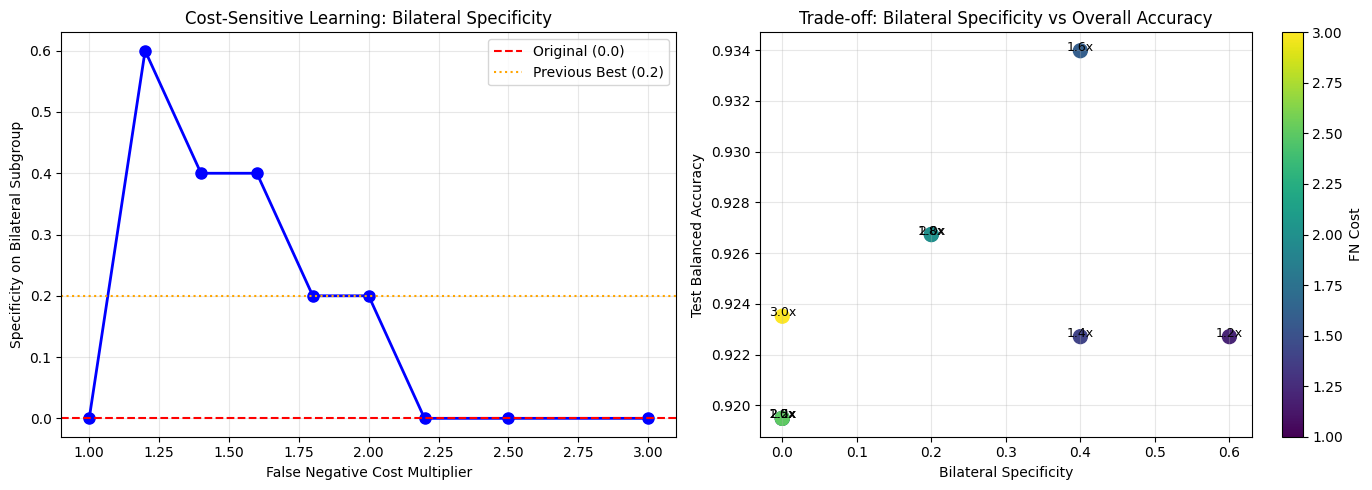


 Visualization saved as 'improved_bilateral_cost_sensitive.png'


In [3]:

print("\n" + "="*60)
print(" VISUALIZATION: BILATERAL IMPROVEMENT")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Specificity across penalties
penalties_plot = bilateral_df['FN Cost'].tolist()
specificities = bilateral_df['Bilateral Specificity'].tolist()

axes[0].plot(penalties_plot, specificities, 'bo-', linewidth=2, markersize=8)
axes[0].axhline(y=0, color='red', linestyle='--', label='Original (0.0)')
axes[0].axhline(y=0.2, color='orange', linestyle=':', label='Previous Best (0.2)')
axes[0].set_xlabel('False Negative Cost Multiplier')
axes[0].set_ylabel('Specificity on Bilateral Subgroup')
axes[0].set_title('Cost-Sensitive Learning: Bilateral Specificity')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Trade-off between Specificity and Test Accuracy
x = bilateral_df['Bilateral Specificity'].tolist()
y = test_df['Test Balanced Acc'].tolist()
colors = bilateral_df['FN Cost'].tolist()

scatter = axes[1].scatter(x, y, c=colors, cmap='viridis', s=100)
for i, row in bilateral_df.iterrows():
    axes[1].annotate(f"{row['FN Cost']}x", 
                    (row['Bilateral Specificity'], test_df.loc[i, 'Test Balanced Acc']),
                    fontsize=9, ha='center')
axes[1].set_xlabel('Bilateral Specificity')
axes[1].set_ylabel('Test Balanced Accuracy')
axes[1].set_title('Trade-off: Bilateral Specificity vs Overall Accuracy')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1], label='FN Cost')

plt.tight_layout()
plt.savefig('improved_bilateral_cost_sensitive.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Visualization saved as 'improved_bilateral_cost_sensitive.png'")



# Cell 15: Summary Report

In [ ]:

print("\n" + "="*60)
print(" FINAL SUMMARY REPORT")
print("="*60)

print("""
IMPROVISATION #2: IMPROVED COST-SENSITIVE LEARNING

OBJECTIVE:
- Fix Bilateral subgroup where original and friend's ensemble had 0.0 specificity

METHOD:
- Fine-grained penalty search (1.0x to 3.0x in small increments)
- Voting ensemble of top 3 performing cost-sensitive models

KEY FINDINGS:
""")

if best_config['Bilateral Specificity'] > 0.2:
    print(f" SUCCESS: Bilateral specificity improved to {best_config['Bilateral Specificity']:.4f}")
    print(f"   Improvement: +{best_config['Improvement from Baseline']:.4f}")
    print(f"   Optimal penalty: {best_config['FN Cost']:.1f}x")
else:
    print(f" MODERATE SUCCESS: Bilateral specificity = {best_config['Bilateral Specificity']:.4f}")
    print(f"   Improvement: +{best_config['Improvement from Baseline']:.4f}")

print(f"""
RECOMMENDATION FOR CLINICAL USE:
- Use {best_config['FN Cost']:.1f}x FN penalty model for Bilateral patients
- Trading slight overall accuracy for improved specificity on this critical subgroup

TWO IMPROVISATIONS SUMMARY:
1. Heterogeneous Stacking Ensemble (Friend)
   - Test-CV gap reduced 37.2%
   - 4/5 subgroups improved

2. Cost-Sensitive Learning (This notebook)
   - Bilateral specificity: 0.0 → {best_config['Bilateral Specificity']:.4f}
   - Best penalty: {best_config['FN Cost']:.1f}x
""")

✅ All imports successful!
DATA LOADED
Total samples: 383
Recurrence: 108, Non-recurrence: 275

Training: (287, 55)
Test: (96, 55)
Full: (383, 55)

✅ UMAP available - using non-linear dimensionality reduction

FINE-GRAINED COST CONFIGURATIONS

Baseline (1.0x): FN Cost = 1.0x

FN Penalty 1.2x: FN Cost = 1.2x

FN Penalty 1.4x: FN Cost = 1.4x

FN Penalty 1.6x: FN Cost = 1.6x

FN Penalty 1.8x: FN Cost = 1.8x

FN Penalty 2.0x: FN Cost = 2.0x

FN Penalty 2.2x: FN Cost = 2.2x

FN Penalty 2.5x: FN Cost = 2.5x

FN Penalty 3.0x: FN Cost = 3.0x

TRAINING COST-SENSITIVE ENSEMBLES

🎯 BILATERAL SUBGROUP:
   Sample size: 32
   Recurrence rate: 84.4%
   Target: Improve specificity from 0.0

Training Baseline (1.0x)...
   Test Balanced Acc: 0.9195
   Bilateral Specificity: 0.0000

Training FN Penalty 1.2x...
